1. UPLOAD DATASETNYA KAGGLE

In [ ]:
%pip install kagglehub tensorflow scikit-learn opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 801.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 72.4 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import kagglehub

path = kagglehub.dataset_download("indk214/brain-tumor-dataset-segmentation-and-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-dataset-segmentation-and-classification' dataset.
Path to dataset files: /kaggle/input/brain-tumor-dataset-segmentation-and-classification


In [ ]:
import os

for root, dirs, fnames in os.walk(path):
    print(root, "->", len(fnames), "files")

/kaggle/input/brain-tumor-dataset-segmentation-and-classification -> 0 files
/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET -> 0 files
/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/Segmentation -> 0 files
/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/Segmentation/Pituitary tumor -> 1860 files
/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/Segmentation/Meningioma -> 1416 files
/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/Segmentation/Glioma -> 1108 files
/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/classification -> 0 files
/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/classification/Training -> 0 files
/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/classification/Training/pituitary -> 1457 files
/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASE

2. PREPROCCES DATA

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE     = 224  # ukuran gambar asli untuk preprocessing & visualisasi (sejernih tampilan di Colab)
FEATURE_SIZE = 64   # gambar di-downscale ke ukuran ini sebelum di-flatten jadi fitur ANN/SVM, supaya sepadan dengan ukuran Dense layer & akurasi tetap terjaga

CLASSES  = ['glioma', 'meningioma', 'notumor', 'pituitary']

train_dir = os.path.join(path, 'DATASET', 'classification', 'Training')
test_dir  = os.path.join(path, 'DATASET', 'classification', 'Testing')

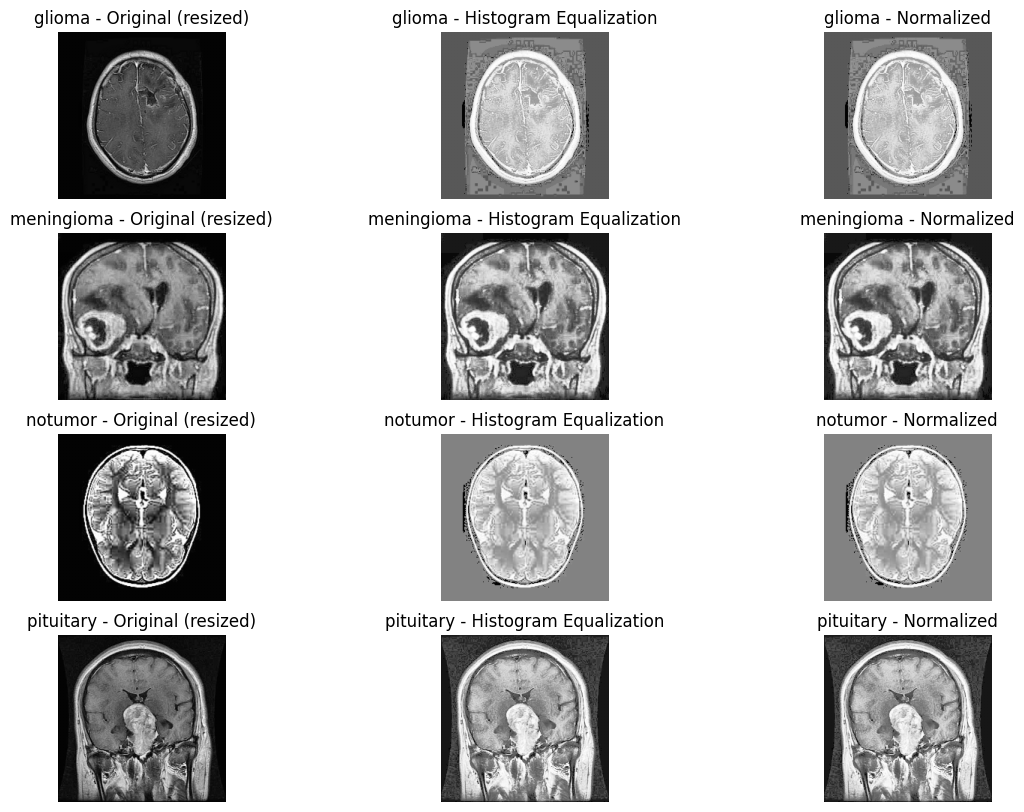

In [ ]:
plt.figure(figsize=(14, 10))

for i, cls in enumerate(CLASSES):
    cls_dir  = os.path.join(train_dir, cls)
    img_path = os.path.join(cls_dir, os.listdir(cls_dir)[0])

    original  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    resized   = cv2.resize(original, (IMG_SIZE, IMG_SIZE))
    equalized = cv2.equalizeHist(resized)
    normalized = equalized / 255.0

    plt.subplot(4, 3, i*3 + 1)
    plt.imshow(resized, cmap='gray')
    plt.title((cls) + ' - Original (resized)')
    plt.axis('off')

    plt.subplot(4, 3, i*3 + 2)
    plt.imshow(equalized, cmap='gray')
    plt.title((cls) + ' - Histogram Equalization')
    plt.axis('off')

    plt.subplot(4, 3, i*3 + 3)
    plt.imshow(normalized, cmap='gray', vmin=0, vmax=1)
    plt.title((cls) + ' - Normalized')
    plt.axis('off')


plt.show()

3. FIND TRAINING AND TEST DATA

In [ ]:
def load_dataset(data_dir):
    X = []
    y = []
    paths = []
    for label, cls in enumerate(CLASSES):
        cls_dir = os.path.join(data_dir, cls)
        files   = os.listdir(cls_dir)   # full dataset, tidak dibatasi per kelas
        for img_name in files:
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.equalizeHist(img)
            feat = cv2.resize(img, (FEATURE_SIZE, FEATURE_SIZE)).astype(np.float32) / 255.0
            X.append(feat.flatten())
            y.append(label)
            paths.append(img_path)
    return np.array(X), np.array(y), paths

print("Loading training data (full dataset)...")
X_train, y_train, paths_train = load_dataset(train_dir)

print("Loading testing data (full dataset)...")
X_test, y_test, paths_test = load_dataset(test_dir)

idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]
paths_train      = [paths_train[i] for i in idx]

print("X_train: " + str(X_train.shape))
print("X_test : " + str(X_test.shape))
assert len(X_train) > len(X_test), "Data training harus lebih besar daripada data testing"

Loading training data (full dataset)...
Loading testing data (full dataset)...
X_train: (5712, 4096)
X_test : (1311, 4096)


In [ ]:
# Distribusi kelas
train_counts = [np.sum(y_train == i) for i in range(len(CLASSES))]
test_counts  = [np.sum(y_test == i)  for i in range(len(CLASSES))]

print("Training:", train_counts)
print("Testing: ", test_counts)

Training: [np.int64(1321), np.int64(1339), np.int64(1595), np.int64(1457)]
Testing:  [np.int64(300), np.int64(306), np.int64(405), np.int64(300)]


4. ADD INPUT LAYER, HIDDEN LAYER, OUTPUT LAYER

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- ANN ---
y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat  = to_categorical(y_test,  num_classes=4)

ann_model = Sequential([
    # Input Layer
    Input(shape=(FEATURE_SIZE * FEATURE_SIZE,)),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    # Hidden Layer
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    # Output Layer
    Dense(4, activation='softmax')
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

# --- SVM ---
svm_model = SVC(kernel='rbf', C=10, gamma='scale')
print("\nSVM model siap:", svm_model)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,476 (8.64 MB)

 Trainable params: 2,263,940 (8.64 MB)

 Non-trainable params: 1,536 (6.00 KB)


SVM model siap: SVC(C=10)


5. TRAINING THE MODEL

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Training ANN
print("Training ANN...")
history = ann_model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks
)

Training ANN...
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7751 - loss: 0.6420 - val_accuracy: 0.4895 - val_loss: 1.6679 - learning_rate: 0.0010
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8840 - loss: 0.3362 - val_accuracy: 0.7500 - val_loss: 0.7857 - learning_rate: 0.0010
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9144 - loss: 0.2380 - val_accuracy: 0.8497 - val_loss: 0.4263 - learning_rate: 0.0010
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9315 - loss: 0.1883 - val_accuracy: 0.7483 - val_loss: 0.8718 - learning_rate: 0.0010
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9498 - loss: 0.1413 - val_accuracy: 0.8147 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9527 - loss: 0.1387 - val_accuracy: 0.8916 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9667 - loss: 

In [ ]:
# Training SVM
print("Training SVM...")
svm_model.fit(X_train, y_train)
print("SVM training selesai.")

Training SVM...
SVM training selesai.


6. TESTING THE MODEL

In [ ]:
# Evaluasi ANN
ann_loss, ann_acc = ann_model.evaluate(X_test, y_test_cat, verbose=0)
y_pred_ann = np.argmax(ann_model.predict(X_test, verbose=0), axis=1)

# Evaluasi SVM
y_pred_svm = svm_model.predict(X_test)
svm_acc    = accuracy_score(y_test, y_pred_svm)

print(f"  ANN Accuracy : {ann_acc*100:.2f}%")
print(f"  SVM Accuracy : {svm_acc*100:.2f}%")

if ann_acc >= svm_acc:
    winner       = "ANN"
    y_pred_final = y_pred_ann
else:
    winner       = "SVM"
    y_pred_final = y_pred_svm

print(f"  >> Metode terpilih: {winner}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=CLASSES))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

  ANN Accuracy : 93.06%
  SVM Accuracy : 96.03%
  >> Metode terpilih: SVM

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.92      0.94       300
  meningioma       0.92      0.92      0.92       306
     notumor       0.98      1.00      0.99       405
   pituitary       0.98      0.99      0.99       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311

Confusion Matrix:
[[275  25   0   0]
 [ 11 281   9   5]
 [  0   0 405   0]
 [  1   1   0 298]]


7. PREDICT

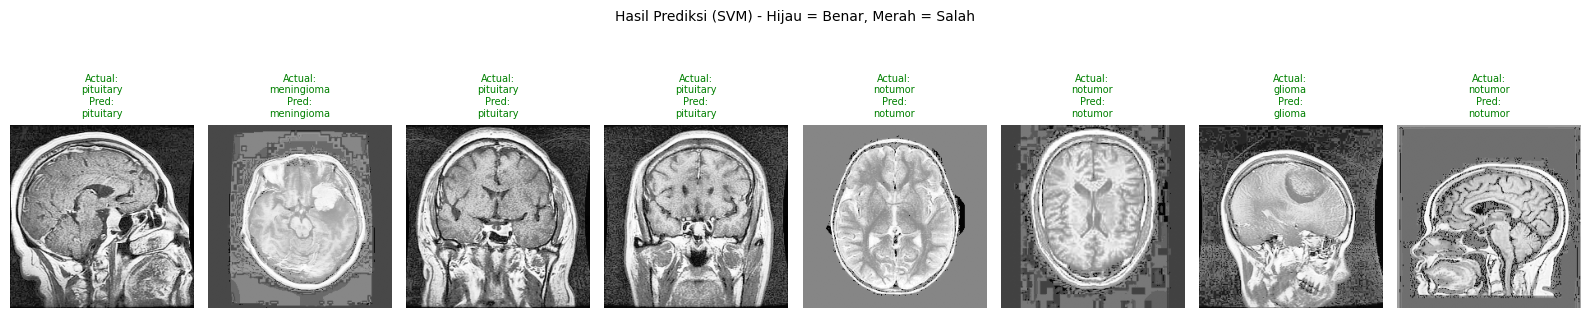

In [ ]:
sample_indices = np.random.choice(len(y_test), 8, replace=False)

plt.figure(figsize=(16, 4))

for i, idx in enumerate(sample_indices):
    img_full = cv2.imread(paths_test[idx], cv2.IMREAD_GRAYSCALE)
    img_full = cv2.resize(img_full, (IMG_SIZE, IMG_SIZE))
    img_full = cv2.equalizeHist(img_full)

    actual    = CLASSES[y_test[idx]]
    predicted = CLASSES[y_pred_final[idx]]

    plt.subplot(1, 8, i + 1)
    plt.imshow(img_full, cmap='gray', vmin=0, vmax=255)
    color = 'green' if actual == predicted else 'red'
    plt.title(f'Actual:\n{actual}\nPred:\n{predicted}', fontsize=7, color=color)
    plt.axis('off')

plt.suptitle(f'Hasil Prediksi ({winner}) - Hijau = Benar, Merah = Salah', fontsize=10)
plt.tight_layout()
plt.show()

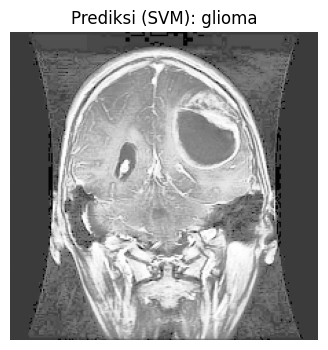

Model    : SVM
Prediksi : glioma


In [ ]:
# Prediksi satu gambar spesifik
def predict_single(img_path):
    img_full = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_full = cv2.resize(img_full, (IMG_SIZE, IMG_SIZE))
    img_full = cv2.equalizeHist(img_full)

    feat = cv2.resize(img_full, (FEATURE_SIZE, FEATURE_SIZE)).astype(np.float32) / 255.0
    img_flat = feat.flatten().reshape(1, -1)

    if winner == 'ANN':
        pred = ann_model.predict(img_flat, verbose=0)
        pred_label  = CLASSES[np.argmax(pred)]
        confidence  = np.max(pred) * 100
        probs       = pred[0]
    else:
        pred_label  = CLASSES[svm_model.predict(img_flat)[0]]
        confidence  = None
        probs       = None

    plt.figure(figsize=(4, 4))
    plt.imshow(img_full, cmap='gray', vmin=0, vmax=255)
    title = f'Prediksi ({winner}): {pred_label}'
    if confidence:
        title += f'\nKepercayaan: {confidence:.1f}%'
    plt.title(title)
    plt.axis('off')
    plt.show()

    print(f"Model    : {winner}")
    print(f"Prediksi : {pred_label}")
    if probs is not None:
        for cls, prob in zip(CLASSES, probs):
            print(f"  {cls:12s}: {prob*100:.2f}%")

# Contoh - ganti path sesuai gambar yang mau diprediksi
sample_path = os.path.join(test_dir, 'glioma', os.listdir(os.path.join(test_dir, 'glioma'))[0])
predict_single(sample_path)

8. UI INTERAKTIF (GRADIO)

In [ ]:
%pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.0/134.0 kB 15.6 MB/s eta 0:00:00


In [ ]:
import gradio as gr

def classify_image(image):
    if image is None:
        return {cls: 0.0 for cls in CLASSES}

    img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.equalizeHist(img)

    feat = cv2.resize(img, (FEATURE_SIZE, FEATURE_SIZE)).astype(np.float32) / 255.0
    img_flat = feat.flatten().reshape(1, -1)

    if winner == 'ANN':
        pred  = ann_model.predict(img_flat, verbose=0)[0]
        probs = {cls: float(p) for cls, p in zip(CLASSES, pred)}
    else:
        pred_label = svm_model.predict(img_flat)[0]
        probs = {cls: (1.0 if i == pred_label else 0.0) for i, cls in enumerate(CLASSES)}

    return probs

demo = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="numpy", label="Upload citra MRI otak"),
    outputs=gr.Label(num_top_classes=4, label=f"Hasil Klasifikasi ({winner})"),
    title="Klasifikasi Tumor Otak (ANN & SVM)",
    description="Upload citra MRI otak untuk diklasifikasikan ke salah satu dari: glioma, meningioma, notumor, pituitary.",
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://da820902e5d57dbe61.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
